In [2]:
import os
import sys
from os import path
sys.path.insert(0, "/home/thomasb")
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import importlib
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.correlations import baseband_data_classes as bdc
importlib.reload(butils)
importlib.reload(bdc)

BDC is using numpy
BDC is using numpy


<module 'albatros_analysis.src.correlations.baseband_data_classes' from '/home/thomasb/albatros_analysis/src/correlations/baseband_data_classes.py'>

This is a demo of how to get the present baseband files for each antenna. We sort contiguous chunks of data into "batches", which are at most a day long due to antenna resets every 24 hrs. However, due to interruptions, they may be shorter, hence the need to check file presence. This also doubles as a config file generator, facilitating analysis.

In [5]:
def get_bline_dist(coord1, coord2):
    ''' 
    returns the physical distance between two coordinates in meters
    (i.e. magnitude of baseline vectors)
    '''
    lat1, lon1, alt1 = coord1[0], coord1[1], coord1[2]
    lat2, lon2, alt2 = coord2[0], coord2[1], coord2[2]

    mean_lat = np.radians((lat1 + lat2) / 2)

    meters_per_deg_lat = 111_320 
    meters_per_deg_lon = 111_320 * np.cos(mean_lat)

    delta_lat_deg = lat2 - lat1
    delta_lon_deg = lon2 - lon1
    delta_alt = float(alt2 - alt1)

    delta_lat_m = float(delta_lat_deg * meters_per_deg_lat)
    delta_lon_m = float(delta_lon_deg * meters_per_deg_lon)

    dist_total = np.sqrt(delta_lat_m**2 + delta_lon_m**2 + delta_alt**2)

    return dist_total

In [6]:
#big interval to catch everything
ant_idxs = np.array([0, 1, 3, 4, 5, 6, 7])
interval_start, interval_end = 1761980000, 1762500000

In [7]:
ant_paths_all = np.array([
    '/project/rrg-sievers/albatros/mars/202507/mars1/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars2/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars3/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars4/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars5',
    '/project/rrg-sievers/albatros/mars/202507/mars6/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars7/baseband',
    '/project/rrg-sievers/albatros/mars/202507/mars8/baseband'
])

#ant_codes_all=np.array(['ALB1','ALB2','ALB3','ALB4','ALB5','ALB6','ALB7','ALB8'])
ant_names_all=np.array(["MARS1","MARS2","MARS3","MARS4","MARS5","MARS6","MARS7","MARS8"])

ant_coords_all = np.array([
[79.41716147,	-90.76723869,	187.9577],	#MARS1
[79.41719805,	-90.75873919,	183.0684],	#MARS2		
[79.41540905,	-90.77299123,	180.4816],	#MARS3			
[79.38845641,	-91.01920296,	25.1938],	#MARS4
[79.41830257,	-90.66739545,	59.6242],	#MARS5			
[79.39798424,	-90.79984241,	41.699],	#MARS6			
[79.41147412,	-90.69526613,	31.6314],	#MARS7				
[79.44375769,	-90.71820263,	414.9131]])	#MARS8				


ant_paths = ant_paths_all[ant_idxs]
ant_names = ant_names_all[ant_idxs]
#ant_codes = ant_codes_all[ant_idxs]
ant_coords = ant_coords_all[ant_idxs]

0
1
2
3
4
5
6
1761979930 1762500000
raw file ant 0 ['/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006230.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006283.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006337.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006390.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006444.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006498.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006551.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006605.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006659.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006713.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006767.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband

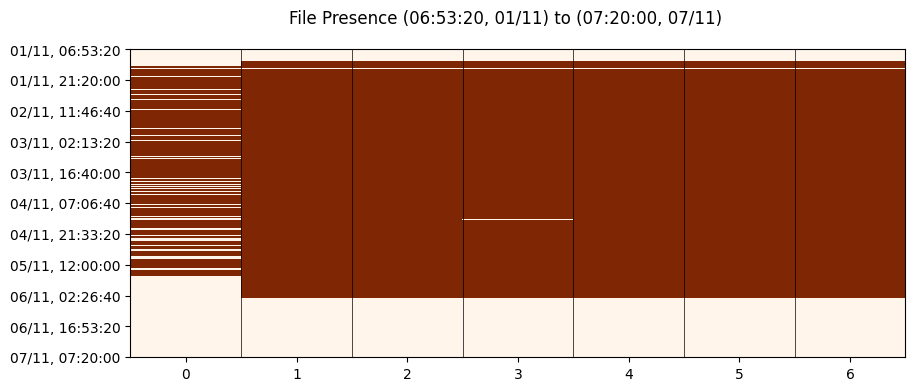

In [8]:
arr, fig = butils.get_present_files(interval_start, interval_end, ant_paths, T_SCAN = 5)

In [10]:
runs = butils.get_simul_files(arr, 1761980000, 5, [1, 2, 3, 4, 5, 6])
print(runs)

[[1762000055, 1762012810], [1762012955, 1762035135], [1762035165, 1762035645], [1762035675, 1762035725], [1762035780, 1762036850], [1762036880, 1762036985], [1762037020, 1762037285], [1762037315, 1762037685], [1762037710, 1762099215], [1762099360, 1762185620], [1762185755, 1762267835], [1762267860, 1762272025], [1762272160, 1762358430], [1762358570, 1762380595], [1762380625, 1762382610], [1762382640, 1762400000]]


In [11]:
for i, r in enumerate(runs):
    print(i, r[0], r[1], r[1]-r[0])

0 1762000055 1762012810 12755
1 1762012955 1762035135 22180
2 1762035165 1762035645 480
3 1762035675 1762035725 50
4 1762035780 1762036850 1070
5 1762036880 1762036985 105
6 1762037020 1762037285 265
7 1762037315 1762037685 370
8 1762037710 1762099215 61505
9 1762099360 1762185620 86260
10 1762185755 1762267835 82080
11 1762267860 1762272025 4165
12 1762272160 1762358430 86270
13 1762358570 1762380595 22025
14 1762380625 1762382610 1985
15 1762382640 1762400000 17360


In [12]:
idx = 8

batch_start_ts = runs[idx][0]
batch_end_ts = runs[idx][1]

print(batch_start_ts)
print(batch_end_ts)
print(batch_end_ts-batch_start_ts)

1762037710
1762099215
61505


In [14]:
# do a coordinate check
coord_errors_all = {}

for i, ant_name in enumerate(ant_names):
    print(f"\n{ant_name}")

    coord_errors = []
    tests = np.linspace(0, 5e4, 10)

    for dt in tests:
        try:
            fname, _ = butils.get_file_from_timestamp(batch_start_ts + dt,ant_paths[i],"f",)
        except Exception:
            print('no data here')
            continue
        d = bdc.Baseband(fname)
        coords_file = np.array([d.gps_latitude,d.gps_longitude,d.gps_elevation])
        coord_error = get_bline_dist(coords_file, ant_coords[i])
        coord_errors.append(coord_error)

    for j, err in enumerate(coord_errors, start=1):
        print(f"error{j}: {err}")

    final_error = min(coord_errors)

    if final_error > 100:
        print('FISHY BUSINESS')
        if final_error < 1e8:
            print('probably just didnt record')
        else:
            raise Exception(f"{ant_name}: Baseband file coordinates disagree with measurements! (no bug)")

    print("Final:", final_error)
    coord_errors_all[str(ant_name)] = int(final_error)

print(coord_errors_all)


MARS1
took 0.090 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762037685.raw
took 0.094 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762043220.raw
took 0.088 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762048819.raw
took 0.085 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762054337.raw
took 0.092 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762059882.raw
took 0.087 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762065469.raw
took 0.075 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762071002.raw
no data here
no data here
took 0.577 seconds to read raw data on  /project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762087664.raw
error1: 27.831713375791

In [25]:
#make the config files
file = {}

antennas = {}
nant = len(ant_names)
for j in range(nant):
    antennas[ant_names[j]] = {}
    antennas[ant_names[j]]["name"] = ant_names[j]
    antennas[ant_names[j]]["path"] = ant_paths[j]
    antennas[ant_names[j]]["coordinates"] = list(ant_coords[j])
file['antennas'] = antennas
file["correlation"] = {
    "start_timestamp": batch_start_ts,
    "end_timestamp": batch_end_ts,
    "vis_acclen": 30000,
    "coarse_acclen": 3000000,
    "osamp": 64,
    "pfb_size": 65536,
    "new_acclen": 1024
}
file["frequency"] = {
    "start_channel": 1834,
    "end_channel": 1852
}

# dump the config files
with open(os.path.join('/home/thomasb/albatros_analysis/scripts/orbcomm/config', f'nov25_batch_{batch_start_ts}.json'), 'w') as f:
    json.dump(file, f, indent=4)


#make the job file
job_name = f"satdet_nov25_{batch_start_ts}"
outfile = f"/scratch/thomasb/job_outs/{job_name}.out"
config = f"/home/thomasb/albatros_analysis/scripts/orbcomm/config/nov25_batch_{batch_start_ts}.json"

ant_string = " ".join(map(str, ant_idxs))

script = f"""#!/bin/bash
#SBATCH --job-name={job_name}
#SBATCH --output={outfile}
#SBATCH --nodes=1
#SBATCH --gpus-per-node=4
#SBATCH --time=08:00:00

# activate tgset
source /home/thomasb/albatros_analysis/src/setup_gpu.sh

# check GPU allocation
srun nvidia-smi

# run satdet
srun python /home/thomasb/albatros_analysis/scripts/orbcomm/get_satdet.py {config}
"""

#dump the job file
with open(os.path.join('jobs', f"{job_name}.sh"), "w") as f:
    f.write(script)

Playing around with how I would open and check file presence for MARS1 (with spotty data)

I want to make sure that when I open data up for MARS1, it's all there and there are no holes. That will involve checking three things: file size, time difference BETWEEN files, and time difference between start, end times and present files.

If there is anything wrong at any point, I will skip the pulse.

In [36]:
#some satellite pass
pass_start_unix = 1762050000
pass_end_unix =   1762052000
dir = '/project/rrg-sievers/albatros/mars/202507/mars1/baseband'

In [18]:
#some satellite pass
pass_start_unix = 1762050000
pass_end_unix =   1762052000
dir = '/project/rrg-sievers/albatros/mars/202507/mars1/baseband'

files, idx = butils.get_init_info(pass_start_unix, pass_end_unix, dir)
print(files)

/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050000.raw
1762050000 1762051960
['/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050000.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050053.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050108.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050161.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050216.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050269.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050322.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050377.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050431.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050484.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762050538.raw', '/projec

In [ ]:
tstamps = []
for f in files:
    #check that the file is full
    size = os.path.getsize(f)
    assert size == 500001224
    #add timestamp to list
    num = int(os.path.splitext(os.path.basename(f))[0])
    tstamps.append(num)
    print(num)

tstamps = np.array(tstamps)

1762050000
1762050053
1762050108
1762050161
1762050216
1762050269
1762050322
1762050377
1762050431
1762050484
1762050538
1762050592
1762050645
1762050699
1762050753
1762050805
1762050860
1762050914
1762050967


AssertionError: 

In [16]:
diff_to_start = tstamps[0]-pass_start_unix
assert diff_to_start<60
print('diff to start', diff_to_start)
diff_to_end = pass_end_unix -tstamps[-1]
assert diff_to_end<60
print('diff to end', diff_to_end)

diff to start -12
diff to end 51


In [17]:
diff_between = np.diff(tstamps)
assert np.all(diff_between<60)
print('diff between', diff_between)

diff between [55 53 55 53 54 54 53 54 54 53 53 54 55 52 54 55]


In [ ]:
#test the actual function
print(butils.check_data_holes(1762037710.0, 1762037759.152, '/project/rrg-sievers/albatros/mars/202507/mars1/baseband'))

Here I will be playing around with overflow file finder for MARS 1

In [3]:
from albatros_analysis.scripts.xcorr import helper as hxc

In [4]:
batch_start_ts = 1762037710

In [68]:
#first we find all files between start and end. we don't mind the gap because there may be files missing
files = butils.time2fnames(
            1762000000,
            1762100000,
            '/project/rrg-sievers/albatros/mars/202507/mars1/baseband',
            "f",
            mind_gap=False,
        )
print(files)

files.sort()
files = np.asarray(files,dtype=object)

# #we iterate through all files and check if there are any empty files
# for file in files:
#     size = os.path.getsize(file)
#     if size>0:
#         files_clean.append(file)

# files_clean = np.asarray(files_clean,dtype=object)

#now that each file is sure to be good, we find THE FIRST NONEMPTY FILE WITH AN OVERFLOW
specnums = []
for file in files:
    try:
        obj = bdc.Baseband(file,readlen=1,verbose=False)
        specnums.append(obj.spec_num[0])
    except Exception:
        print('empty file')
        specnums.append(specnums[-1])

wrap_loc = np.where(np.diff(specnums)<0)[0]
print(np.asarray([butils.get_tstamp_from_filename(f) for f in files[wrap_loc]],dtype='int64'))

1762000000 1762100000
['/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006230.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006283.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006337.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006390.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006444.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006498.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006551.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006605.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006659.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006713.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006767.raw', '/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762006820.raw', '/pro

In [66]:
obj = bdc.Baseband('/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762067026.raw',readlen=1,verbose=False)
print(obj.spec_num[0])
obj = bdc.Baseband('/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762067081.raw',readlen=1,verbose=False)
print(obj.spec_num[0])


obj = bdc.Baseband('/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762067134.raw',readlen=1,verbose=False)
print(obj.spec_num[0])
obj = bdc.Baseband('/project/rrg-sievers/albatros/mars/202507/mars1/baseband/17620/1762068070.raw',readlen=1,verbose=False)
print(obj.spec_num[0])
print(2**32)

104856400
108135088
111413776
3223448
4294967296


In [43]:
importlib.reload(hxc)

of = hxc.get_overflow_files2(1762000000,1762090000,'/project/rrg-sievers/albatros/mars/202507/mars1/baseband')
print(of)

1762000000 1762090000
[1762007573 1762010088 1762012788 1762015420 1762018148 1762020753
 1762023386 1762026065 1762028791 1762031507 1762034198 1762037135
 1762042628 1762045369 1762048154 1762051021 1762053677 1762056431
 1762059209 1762062030 1762064949 1762067672 1762070593 1762073313
 1762076223 1762079240 1762082036 1762085009 1762087880]
None
